In [1]:
import sys
sys.path.append('..')

import src.data_prep as data_prep
import src.train as train
import src.evaluate as evaluate

In [2]:
df = data_prep.load_german_credit('../data/raw/german_credit/german.data')

X_train, X_test, y_train, y_test, scaler = data_prep.prepare_data(df)

print("Dane wczytane i przygotowane")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Dane wczytane i przygotowane
X_train shape: (800, 48)
X_test shape: (200, 48)


In [3]:
log_reg = train.train_logistic_regression(X_train, y_train)

metrics_lr, y_pred_lr, y_pred_proba_lr = evaluate.evaluate_model(log_reg, X_test, y_test)

evaluate.print_metrics(metrics_lr, "Regresja Logistyczna")

--- Regresja Logistyczna ---
Accuracy: 0.740
Precision: 0.547
Recall: 0.783
F1=score: 0.644
ROC_AUC: 0.807


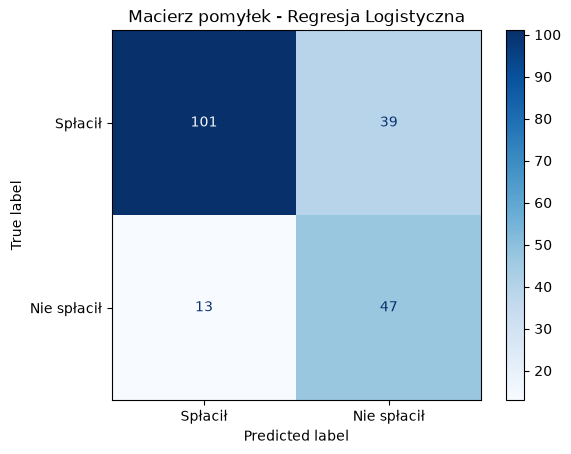

In [4]:
evaluate.plot_confusion_matrix(y_test, y_pred_lr, "Regresja Logistyczna")

In [6]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(log_reg, '../models/model.pk1')
joblib.dump(scaler, '../models/scaler.pk1')
joblib.dump(X_train.columns.tolist(), '../models/columns.pk1')

print("Zapisano model, scaler i listę kolumn.")

Zapisano model, scaler i listę kolumn.


In [8]:
import src.predict as predict

nowy_klient = {
    'status_konta': 'A11',
    'czas_trwania_msc': 24,
    'historia_kredytowa': 'A32',
    'cel_kredytu': 'A43',
    'kwota_kredytu': 5000,
    'stan_oszczednosci': 'A61',
    'zatrudnienie_od': 'A73',
    'raty_proc_dochodu': 3,
    'stan_cywilny_plec': 'A93',
    'inni_dluznicy': 'A101',
    'lata_w_miejscu_zamieszkania': 2,
    'majatek': 'A121',
    'wiek': 35,
    'inne_raty': 'A143',
    'mieszkanie': 'A152',
    'liczba_kredytow_w_banku': 1,
    'zawod': 'A173',
    'liczba_osob_na_utrzymaniu': 1,
    'telefon': 'A192',
    'pracownik_zagraniczny': 'A201'
}

pred, prob = predict.predict_client(log_reg, nowy_klient, X_train.columns.tolist(), scaler)

print("Predykcja:", pred, "(0 = spłaci, 1 = nie spłaci)")
print(f"Prawdopodobieństwo niespłacenia: {prob:.3f}")

Predykcja: 0 (0 = spłaci, 1 = nie spłaci)
Prawdopodobieństwo niespłacenia: 0.495


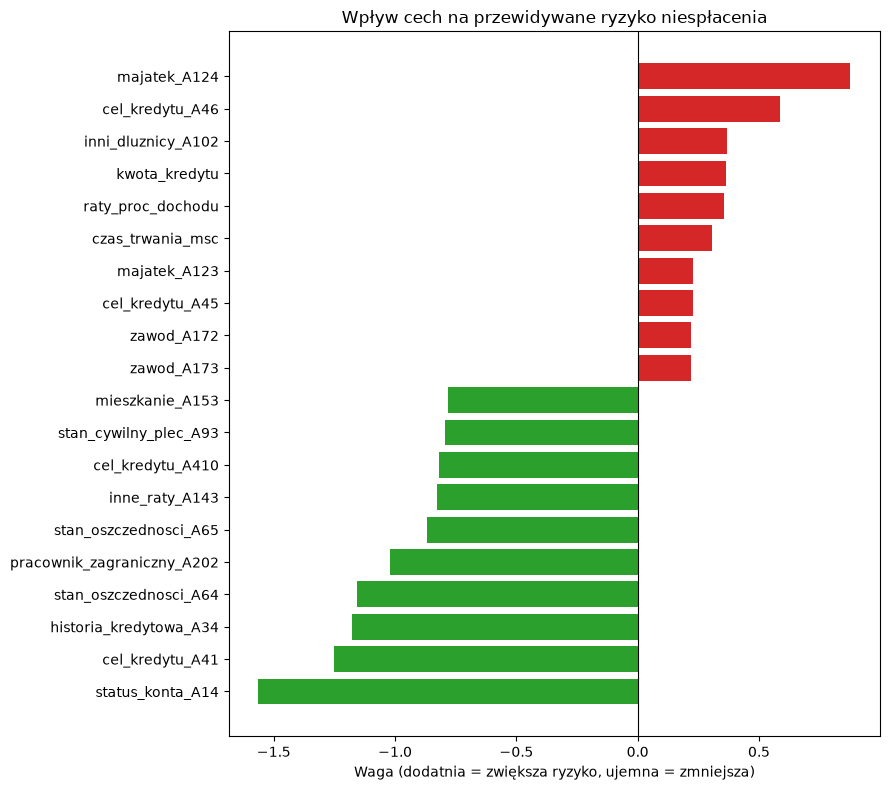

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

wagi = pd.DataFrame({
    'cecha': X_train.columns,
    'waga': log_reg.coef_[0]
}).sort_values('waga')

top = pd.concat([wagi.head(10), wagi.tail(10)])

plt.figure(figsize=(9, 8))
kolory = ['tab:green' if w < 0 else 'tab:red' for w in top['waga']]
plt.barh(top['cecha'], top['waga'], color=kolory)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Wpływ cech na przewidywane ryzyko niespłacenia')
plt.xlabel('Waga (dodatnia = zwiększa ryzyko, ujemna = zmniejsza)')
plt.tight_layout()
plt.show()